# 5 — The contact patch as a PDE: a physics-encoded brush model

Every tyre model so far in this project has been *algebraic*: slip in, force out. The
brush model is not — it is the integral of a **local boundary-value problem along the
contact patch**, and collapsing it to a closed form costs assumptions that are often
wrong.

This notebook keeps the local problem explicit, discretises it into a chain (a 1-D
graph), and learns the one thing that is genuinely unknown — the **pressure
distribution** — while every physical constraint is enforced by construction.

## The local problem

Tread material enters at the leading edge undeflected and is carried through the patch,
so in the adhesion region a bristle's deflection grows with distance travelled:

$$\frac{d\boldsymbol\delta}{d\xi} = \boldsymbol\sigma,
  \qquad \boldsymbol\delta(0) = \mathbf 0,
  \qquad \boldsymbol\tau = k_b\,\boldsymbol\delta$$

and the local shear cannot exceed what friction can carry:

$$\|\boldsymbol\tau(\xi)\| \le \mu\,p(\xi), \qquad
  \mathbf F = \int_0^{2a} \boldsymbol\tau(\xi)\,d\xi$$

Discretising $\xi$ turns the ODE into a cumulative sum along a chain and the integral
into a quadrature. **Units:** everything is a *line* quantity — $p$ is N/m with
$\int p\,d\xi = F_z$, and patch width never appears.

In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import torch

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})
torch.manual_seed(0)

/home/poxx/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Does the discretisation reproduce the closed form?

A discretisation that does not converge to the known answer is not a model, it is a
bug. This is the first thing to check.

In [2]:
from tire_nn.physics.brush_patch import patch_forces, patch_coordinates, parabolic_pressure
from tire_nn.physics.brush import brush_combined

A, KB, MU = 0.06, 6.0e6, 1.0          # half-length [m], line stiffness [N/m^2], friction
C_ALPHA = 2 * A**2 * KB                # implied cornering stiffness
print(f"implied C_alpha = {C_ALPHA:.0f} N/rad")

n = 25
alpha = torch.linspace(0.0, 0.08, n)
Fz = torch.full((n,), 1000.0)
a = torch.full((n,), A)
_, Fy_closed = brush_combined(alpha, torch.zeros(n), Fz, C_ALPHA, C_ALPHA, MU)

print("\nelements   max |discrete - closed form|")
errs = {}
for ne in (8, 32, 128, 512):
    out = patch_forces(torch.zeros(n), torch.tan(alpha), Fz, a,
                       torch.full((n,), KB), torch.full((n,), MU), n_elements=ne)
    errs[ne] = float((out["Fy"] - Fy_closed).abs().max())
    print(f"  {ne:5d}      {errs[ne]:8.4f} N")
print(f"\nerror ratio for 4x elements: {errs[32]/errs[128]:.1f}x  (16x expected for 2nd order)")

implied C_alpha = 43200 N/rad

elements   max |discrete - closed form|
      8        9.7137 N
     32        0.6244 N
    128        0.0348 N
    512        0.0022 N

error ratio for 4x elements: 17.9x  (16x expected for 2nd order)


## 2. What the patch is doing internally

The closed form gives only the total force. The discretised version exposes the
adhesion/sliding split that produces it — the physical mechanism behind the shape of
every tyre curve.

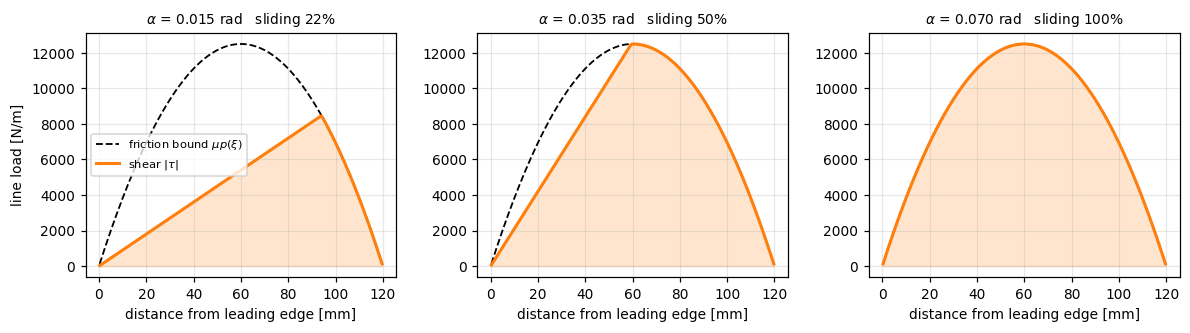

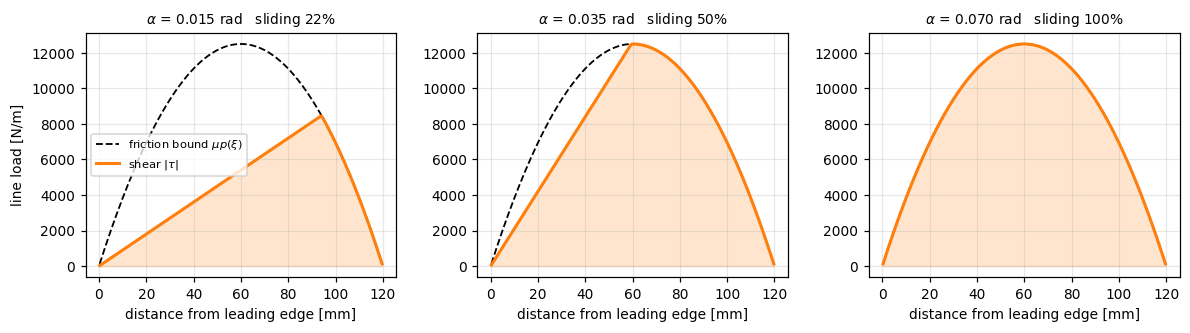

In [3]:
NE = 200
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1))
for ax, slip in zip(axes, [0.015, 0.035, 0.07]):
    a1 = torch.tensor([A]); Fz1 = torch.tensor([1000.0])
    xi, _ = patch_coordinates(NE, a1)
    p = parabolic_pressure(xi, a1, Fz1)
    out = patch_forces(torch.zeros(1), torch.tan(torch.tensor([slip])), Fz1, a1,
                       torch.tensor([KB]), torch.tensor([MU]), n_elements=NE)
    x = xi[0].numpy() * 1000                       # mm from leading edge
    ax.plot(x, (MU * p[0]).numpy(), "k--", lw=1.2, label=r"friction bound $\mu p(\xi)$")
    # tau_y is already the positive magnitude along the slip direction; the SAE sign
    # flip happens only when it is integrated into Fy.
    ax.plot(x, out["tau_y"][0].numpy(), color="tab:orange", lw=2, label=r"shear $|\tau|$")
    ax.fill_between(x, 0, out["tau_y"][0].numpy(), color="tab:orange", alpha=0.2)
    ax.set_title(f"$\\alpha$ = {slip:.3f} rad   sliding {float(out['sliding_fraction']):.0%}", fontsize=9)
    ax.set_xlabel("distance from leading edge [mm]")
axes[0].set_ylabel("line load [N/m]")
axes[0].legend(fontsize=7.5)
fig.tight_layout(); fig

At small slip the shear stays under the friction bound across the whole patch: pure
adhesion. As slip grows the shear meets the bound at the trailing edge first (where the
pressure has fallen) and the sliding region eats forward. **That migration is the tyre
force curve**: its saturation is not a fitted shape, it is where the bound binds.

## 3. The encoded model

Now make the pressure distribution learnable while keeping every constraint exact:

| guarantee | mechanism |
|---|---|
| $p_i \ge 0$ | `softmax` over patch elements |
| $\sum_i p_i\,\Delta\xi = F_z$ | the same `softmax` — it sums to 1 by definition |
| $\|\tau_i\| \le \mu p_i$ | elementwise `min` against the bound |
| force opposes slip | shear built along $-\boldsymbol\sigma$ |
| $F(0)=0$, odd symmetry | zero slip gives zero deflection |
| $\mu, k_b, a$ physical | bounded parameter transforms |

The load balance is the one to dwell on. As a penalty $\lambda(\sum p_i\Delta\xi - F_z)^2$
it holds only on average — and a model that can quietly invent vertical load can fit
almost anything. As a `softmax` it is exact for every weight vector, and costs one
line.

In [4]:
from tire_nn.models.patch_brush_net import PatchBrushNet

model = PatchBrushNet(n_elements=48, learn_pressure=True)
print(model.describe())

# Every guarantee, under deliberately absurd weights.
adversarial = PatchBrushNet(n_elements=48)
with torch.no_grad():
    for p in adversarial.parameters():
        p.normal_(0.0, 10.0)

Fz_test = torch.tensor([300.0, 1000.0, 2500.0])
with torch.no_grad():
    p_test = adversarial.pressure_profile(Fz_test)
    a_test = adversarial.contact_half_length(Fz_test)
_, dxi = patch_coordinates(48, a_test)
print(f"\npressure non-negative      : {bool((p_test >= 0).all())}")
print(f"integrates to Fz           : {(p_test * dxi.unsqueeze(-1)).sum(-1).numpy().round(2)}  (target {Fz_test.numpy()})")

aa = torch.linspace(-0.3, 0.3, 41); kk = aa * 0.4; ff = torch.full((41,), 1000.0)
with torch.no_grad():
    o, om = adversarial(aa, kk, ff), adversarial(-aa, -kk, ff)
    zero_force = float(adversarial(torch.zeros(3), torch.zeros(3), Fz_test).Fy.abs().max())
print(f"odd symmetric              : {bool(torch.allclose(o.Fy, -om.Fy, atol=1e-4))}")
print(f"zero force at zero slip    : {zero_force:.1e}")
mag = torch.sqrt(o.Fx**2 + o.Fy**2)
print(f"peak friction utilisation  : {float((mag / (o.params['mu_x'] * ff)).max()):.4f}")

PatchBrushNet(elements=48, params=2708, learn_pressure=True)

pressure non-negative      : True
integrates to Fz           : [ 300. 1000. 2500.]  (target [ 300. 1000. 2500.])
odd symmetric              : True
zero force at zero slip    : 0.0e+00
peak friction utilisation  : 0.2666


## 4. A tyre the parabolic assumption cannot represent

Real contact patches are not parabolic — load, inflation pressure, camber and wear all
reshape them. Here is a skewed, flat-topped profile of the kind a worn or over-inflated
tyre can carry. We generate force data from it and ask both models to fit.

In [5]:
NE = 48
n = 400
alpha = torch.linspace(-0.09, 0.09, n)
Fz = torch.full((n,), 1000.0)
a = torch.full((n,), A)
xi, _ = patch_coordinates(NE, a)

u = xi / (2 * a.unsqueeze(-1))
shape = torch.clamp(u, min=1e-6) ** 2.2 * torch.clamp(1 - u, min=1e-6) ** 0.9
dxi = (2 * a / NE).unsqueeze(-1)
p_true = shape / (shape * dxi).sum(-1, keepdim=True) * Fz.unsqueeze(-1)

truth = patch_forces(torch.zeros(n), torch.tan(alpha), Fz, a,
                     torch.full((n,), KB), torch.full((n,), MU),
                     pressure=p_true, n_elements=NE)
NOISE = 3.0
Fy_data = truth["Fy"] + torch.randn(n) * NOISE
print(f"generated {n} force samples with {NOISE:.0f} N noise from a non-parabolic patch")

generated 400 force samples with 3 N noise from a non-parabolic patch


In [6]:
def fit(model, epochs=1200, lr=0.02):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad(set_to_none=True)
        loss = ((model(alpha, torch.zeros(n), Fz).Fy - Fy_data) ** 2).mean() / 1e6
        loss.backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        return model, float(torch.sqrt(((model(alpha, torch.zeros(n), Fz).Fy - Fy_data) ** 2).mean()))

learned, rmse_learned = fit(PatchBrushNet(n_elements=NE, learn_pressure=True))
parabolic, rmse_parabolic = fit(PatchBrushNet(n_elements=NE, learn_pressure=False))

print(f"learned pressure   RMSE {rmse_learned:5.2f} N   (noise floor {NOISE:.1f} N)")
print(f"parabolic only     RMSE {rmse_parabolic:5.2f} N   -> {rmse_parabolic/rmse_learned:.1f}x worse")
print()
with torch.no_grad():
    a_rec = float(learned.contact_half_length(torch.tensor([1000.0])))
print(f"recovered half-length a = {a_rec:.4f} m   (true {A})")
print(f"recovered mu            = {float(learned.mu().detach()):.3f}   (true {MU})")

learned pressure   RMSE  2.86 N   (noise floor 3.0 N)
parabolic only     RMSE 25.75 N   -> 9.0x worse

recovered half-length a = 0.0600 m   (true 0.06)
recovered mu            = 1.001   (true 1.0)


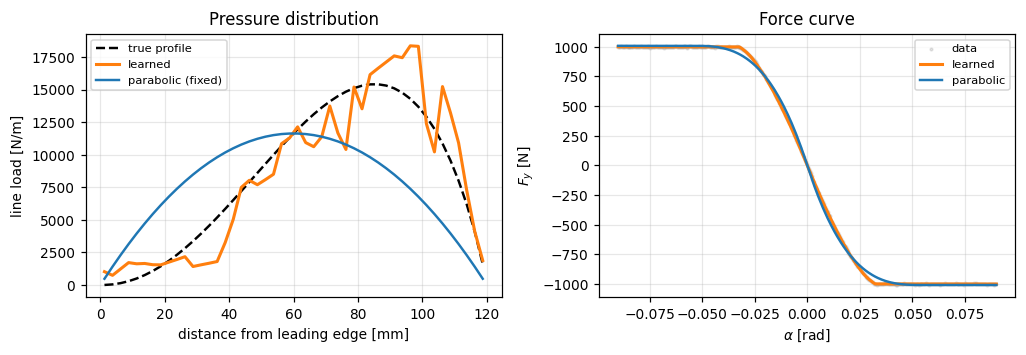

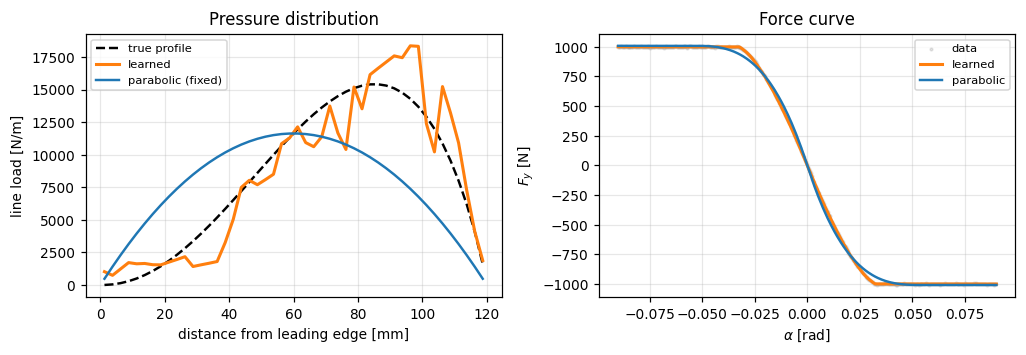

In [7]:
with torch.no_grad():
    p_learned = learned.pressure_profile(torch.tensor([1000.0]))[0]
    p_parab = parabolic.pressure_profile(torch.tensor([1000.0]))[0]

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.3))
x = xi[0].numpy() * 1000
axes[0].plot(x, p_true[0].numpy(), "k--", lw=1.6, label="true profile")
axes[0].plot(x, p_learned.numpy(), color="tab:orange", lw=2, label="learned")
axes[0].plot(x, p_parab.numpy(), color="tab:blue", lw=1.6, label="parabolic (fixed)")
axes[0].set_xlabel("distance from leading edge [mm]"); axes[0].set_ylabel("line load [N/m]")
axes[0].set_title("Pressure distribution"); axes[0].legend(fontsize=7.5)

with torch.no_grad():
    axes[1].scatter(alpha, Fy_data, s=3, alpha=0.25, color="0.6", label="data")
    axes[1].plot(alpha, learned(alpha, torch.zeros(n), Fz).Fy, color="tab:orange", lw=2, label="learned")
    axes[1].plot(alpha, parabolic(alpha, torch.zeros(n), Fz).Fy, color="tab:blue", lw=1.6, label="parabolic")
axes[1].set_xlabel(r"$\alpha$ [rad]"); axes[1].set_ylabel("$F_y$ [N]")
axes[1].set_title("Force curve"); axes[1].legend(fontsize=7.5)
fig.tight_layout(); fig

In [8]:
corr = float(np.corrcoef((p_learned / p_learned.max()).numpy(),
                         (p_true[0] / p_true[0].max()).numpy())[0, 1])
print(f"pressure-shape correlation with the truth: {corr:.3f}")
print()
print("The force curve is fitted to the noise floor, and the recovered profile has the")
print("right character - front-loaded and flat-topped - but the shape is only partly")
print("identifiable: a scalar force curve does not pin down every element of a")
print("48-element distribution. Same lesson as the degradation notebook.")

pressure-shape correlation with the truth: 0.938

The force curve is fitted to the noise floor, and the recovered profile has the
right character - front-loaded and flat-topped - but the shape is only partly
identifiable: a scalar force curve does not pin down every element of a
48-element distribution. Same lesson as the degradation notebook.


## 5. Why not just penalise the constraints?

The load balance could have been a loss term. Here is what that costs: the same model,
with the `softmax` replaced by an unconstrained positive profile plus a penalty.

In [9]:
import torch.nn.functional as Fn

class PenalisedPatch(torch.nn.Module):
    """Same physics, but the load balance is a soft penalty instead of a construction."""
    def __init__(self, n_elements=NE):
        super().__init__()
        self.logits = torch.nn.Parameter(torch.zeros(n_elements))
        self.n_elements = n_elements
    def pressure(self, Fz, a):
        # Scale by Fz/(2a) so softplus(0) already gives a line load of the right order.
        # Starting four orders of magnitude too low would make the comparison a study of
        # initialisation rather than of the constraint.
        scale = (Fz / (2 * a)).unsqueeze(-1)
        return Fn.softplus(self.logits).unsqueeze(0).expand(len(Fz), -1) * scale
    def forward(self, alpha, Fz, a):
        p = self.pressure(Fz, a)
        return patch_forces(torch.zeros(len(alpha)), torch.tan(alpha), Fz, a,
                            torch.full((len(alpha),), KB), torch.full((len(alpha),), MU),
                            pressure=p, n_elements=self.n_elements), p

for weight in (0.0, 1.0, 100.0):
    torch.manual_seed(0)
    pen = PenalisedPatch()
    opt = torch.optim.Adam(pen.parameters(), lr=0.03)
    for _ in range(800):
        opt.zero_grad(set_to_none=True)
        out, p = pen(alpha, Fz, a)
        load = (p * dxi).sum(-1)
        loss = ((out["Fy"] - Fy_data) ** 2).mean() / 1e6 + weight * ((load - Fz) / 1000.0).pow(2).mean()
        loss.backward(); opt.step()
    with torch.no_grad():
        out, p = pen(alpha, Fz, a)
        load_err = float(((p * dxi).sum(-1) - Fz).abs().mean())
        rmse = float(torch.sqrt(((out["Fy"] - Fy_data) ** 2).mean()))
    print(f"penalty weight {weight:6.1f}:  force RMSE {rmse:6.2f} N   "
          f"load-balance error {load_err:7.2f} N ({100*load_err/1000:.1f}% of Fz)")

print(f"\nsoftmax (encoded)      :  force RMSE {rmse_learned:6.2f} N   "
      f"load-balance error    0.00 N (exact, for any weights)")

penalty weight    0.0:  force RMSE  13.46 N   load-balance error   62.63 N (6.3% of Fz)


penalty weight    1.0:  force RMSE   8.14 N   load-balance error    1.89 N (0.2% of Fz)


penalty weight  100.0:  force RMSE  68.00 N   load-balance error    0.43 N (0.0% of Fz)

softmax (encoded)      :  force RMSE   2.86 N   load-balance error    0.00 N (exact, for any weights)


The penalty trades load balance against fit, and the trade is set by a weight nobody
can choose from first principles. Low weight: the model invents vertical load. High
weight: it stops fitting the force. The `softmax` gives an exact constraint *and* the
best fit, with nothing to tune.

## Takeaways

1. **The brush model is a PDE, and keeping it as one is cheap.** A 48-element chain
   reproduces the closed form to second order and runs in milliseconds.
2. **Discretising buys expressiveness that the closed form cannot have.** The
   parabolic-pressure assumption is worth several times the noise floor on a tyre whose
   patch is not parabolic.
3. **Constraints on a *distribution* can be encoded too.** `softmax` gives positivity
   and an exact integral in one operation — the distribution-valued analogue of the
   bounded parameter transforms used elsewhere in this project.
4. **Identifiability stays the honest limit.** The force curve fixes the pressure
   profile's character but not its every detail. Pressure-sensitive measurements (a
   pressure-mapping test bench) would pin it down; force alone does not.